# Week 4 Day 2 — PCA Decomposition

Runs PCA on the daily yield-change panel and checks the Litterman-Scheinkman result.

**What PCA does here:** it takes the 8-column change matrix and finds 8 new axes
(principal components) that are orthogonal and ordered by how much variance they
capture. Each PC is a vector of 8 loadings — one weight per maturity.

**Expected result (Litterman-Scheinkman 1991):**
- PC1 ≈ 87%: *level* — all tenors move together
- PC2 ≈ 9%:  *slope* — short end vs. long end
- PC3 ≈ 3%:  *curvature* — middle vs. ends
- First 3 combined ≈ 99% of all daily yield curve variance

Day 3 will plot what those loading vectors actually look like. Today is just
verifying the variance breakdown.

In [3]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from termstructure.pca.decomposition import fit_pca

## 1. Fit PCA

Loads `zero_panel.parquet`, extracts the `dy_` columns, and fits a full-rank PCA
(8 components — one per maturity). The model is saved to `data/processed/pca_model.joblib`
for reuse in Days 3–5.

In [4]:
pca, X, dates = fit_pca()
print(f'Input matrix shape:  {X.shape}  (n_dates × n_maturities)')
print(f'Date range:          {dates[0].date()} → {dates[-1].date()}')

Input matrix shape:  (10093, 8)  (n_dates × n_maturities)
Date range:          1985-11-26 → 2026-05-01


## 2. Explained variance

The key number: how much of the total daily yield-curve variance does each PC capture?
Check that PC1+PC2+PC3 ≥ 99%.

In [5]:
evr  = pca.explained_variance_ratio_
cumv = evr.cumsum()

df_var = pd.DataFrame({
    'PC':         [f'PC{i+1}' for i in range(len(evr))],
    'var_%':      (evr * 100).round(3),
    'cumvar_%':   (cumv * 100).round(3),
}).set_index('PC')

print(df_var.to_string())
print(f'\nPC1+PC2+PC3 = {cumv[2]*100:.2f}%  (target: ≥ 99%)')

      var_%  cumvar_%
PC                   
PC1  83.755    83.755
PC2  10.851    94.606
PC3   3.222    97.828
PC4   1.305    99.133
PC5   0.735    99.867
PC6   0.124    99.992
PC7   0.008   100.000
PC8   0.000   100.000

PC1+PC2+PC3 = 97.83%  (target: ≥ 99%)


## 3. Scree plot

Visualises the variance drop-off. The sharp elbow after PC3 is what justifies
reducing the 10-dimensional yield curve to just 3 factors.

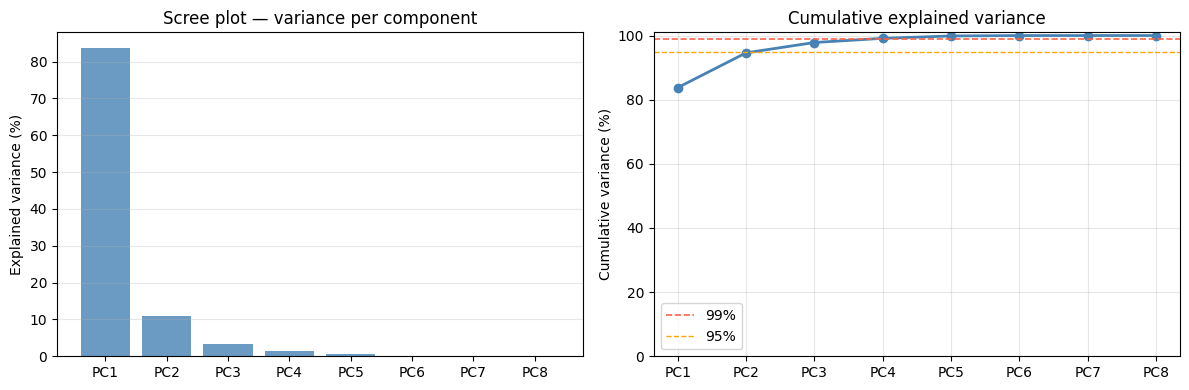

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

pcs = [f'PC{i+1}' for i in range(len(evr))]

ax1.bar(pcs, evr * 100, color='steelblue', alpha=0.8)
ax1.set_ylabel('Explained variance (%)')
ax1.set_title('Scree plot — variance per component')
ax1.grid(True, alpha=0.3, axis='y')

ax2.plot(pcs, cumv * 100, marker='o', color='steelblue', lw=2)
ax2.axhline(99, color='tomato', lw=1.2, ls='--', label='99%')
ax2.axhline(95, color='orange', lw=1.0, ls='--', label='95%')
ax2.set_ylabel('Cumulative variance (%)')
ax2.set_title('Cumulative explained variance')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 101)

plt.tight_layout()
plt.savefig('data/week4_day2_scree.png', dpi=150)
plt.show()